# **Extract ID-Card Elements and Generate Ground Truth**

This notebook has two main objectives:
1. **Crop & Export Elements:** Extract specific ROIs (Document Number, Tramite Number, MRZ, Address, etc.) from Argentine ID-Cards using our fine-tuned YOLOv26 model, saving them into structured directories.
2. **Auto-Generate Ground Truth (Pre-GT):** Use Google Gemini VLM to automatically transcribe the text elements and generate an initial `ground_truth.json` for subsequent human review.

These steps prepare the dataset for benchmarking different OCR engines in the next stage.

## **Expected Input**
* Processed Argentine ID-Card images in `data/prc/ocr_images_examples/front` and `data/prc/ocr_images_examples/back`.
* Trained YOLOv26 detection model (`weights/yolo/yolo26s_ID_elements_det.pt`).

## **Expected Output**
* Cropped image elements stored in `data/prc/ocr_crops/<element_name>/`.
* A JSON file (`data/prc/pre_gt_eval.json`) containing the pre-annotated ground truth.

## **Libraries and Settings**

In [ ]:
from pathlib import Path
from ultralytics import YOLO
from typing import List
from google import genai
from google.genai import types
from google.genai.errors import APIError
from time import sleep
from tqdm import tqdm
import json
import ultralytics
import os
import cv2
import matplotlib.pyplot as plt

if not os.environ.get("BASE_PROJECT_DIR"):
    os.environ["BASE_PROJECT_DIR"] = input("Enter the base project directory path: ")

if not os.environ.get("GOOGLE_API_KEY"):
    os.environ["GOOGLE_API_KEY"] = input("Enter your Google API key: ")

BASE_INPUT_DIR = Path(os.environ.get("BASE_PROJECT_DIR")) / "data/prc/ocr_images_examples"
BASE_MODEL_DIR = Path(os.environ.get("BASE_PROJECT_DIR")) / "weights/yolo"
MODEL_NAME = "yolo26s_ID_elements_det.pt"

model = YOLO(BASE_MODEL_DIR / MODEL_NAME)
front_images = list(Path(BASE_INPUT_DIR / "front").glob("*"))
back_images = list(Path(BASE_INPUT_DIR / "back").glob("*"))

print(f"Ultralytics version: {ultralytics.__version__}")
print(f"OpenCV version: {cv2.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Google GenAI version: {genai.__version__}")

Ultralytics version: 8.4.117
OpenCV version: 4.10.0
Matplotlib version: 3.11.0
Google GenAI version: 2.14.0


## **Example of front elements detections**

Take an image of a front ID-Card and make an inference to detect the elements and show it.

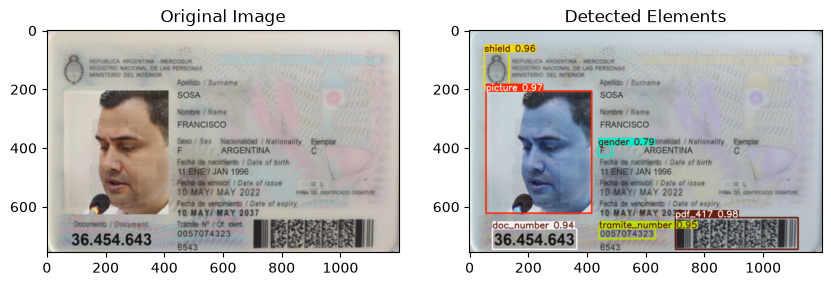

In [2]:
img = cv2.imread(str(front_images[0]))
result = model.predict(source=str(front_images[0]), verbose=False)[0]

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axs[0].set_title("Original Image")
axs[1].imshow(result.plot())
axs[1].set_title("Detected Elements")
plt.show()

## **Example of back elements detections**

Take an image of a back ID-Card and make an inference to detect the elements and show it.

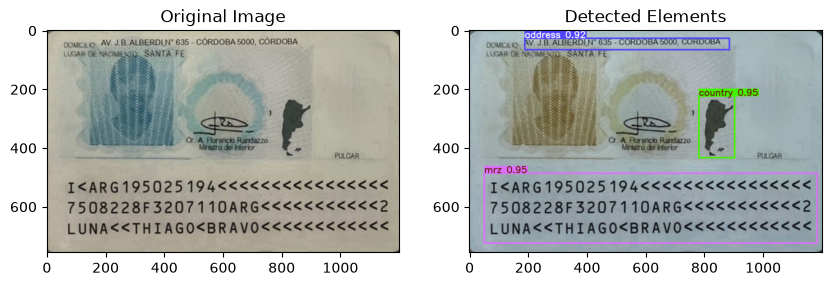

In [3]:
img = cv2.imread(str(back_images[1]))
result = model.predict(source=str(back_images[1]), verbose=False)[0]

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axs[0].set_title("Original Image")
axs[1].imshow(result.plot())
axs[1].set_title("Detected Elements")
plt.show()

## **Extractions and save of the elements**

Now, extract and save each element detected in its corresponding folder.

The folders for eache elementes are the followings:
* `doc_number`
* `tramite_number`
* `mrz`
* `address`

Maintain the original image name for each element.

In [4]:
def extract_and_save_elements(image: Path,
                              model: YOLO,
                              elements_name: List[str]) -> None:

    for element in elements_name:
        if not os.path.exists(str(BASE_INPUT_DIR) + "/" + element):
            directory = Path(BASE_INPUT_DIR / element)
            directory.mkdir(parents=True, exist_ok=True)
            print(f"Directory for {element} was created.")

    img = cv2.imread(str(image))
    result = model.predict(source=str(image), verbose=False)[0]
    boxes = result.boxes.xyxy.cpu().tolist()
    classes = result.boxes.cls.cpu().tolist()
    for box, cls in zip(boxes, classes):
        x1, y1, x2, y2 = map(int, box)

        if cls == 2:
            path = Path(BASE_INPUT_DIR / "doc_number" / image.name)
            cv2.imwrite(str(path), img[y1:y2, x1:x2])
        if cls == 3:
            path = Path(BASE_INPUT_DIR / "tramite_number" / image.name)
            cv2.imwrite(str(path), img[y1:y2, x1:x2])
        if cls == 5:
            path = Path(BASE_INPUT_DIR / "mrz" / image.name)
            cv2.imwrite(str(path), img[y1:y2, x1:x2])
        if cls == 6:
            path = Path(BASE_INPUT_DIR / "address" / image.name)
            cv2.imwrite(str(path), img[y1:y2, x1:x2])

In [52]:
elements = ["doc_number", "tramite_number", "mrz", "address"]

images = front_images + back_images
for image in images:
    extract_and_save_elements(image=image,
                              model=model,
                              elements_name=elements)

## **Automatic Ground Truth Generation (Pre-GT)**

In this stage, we automatically generate an initial ground-truth file for each extracted DNI element (`doc_number`, `tramite_number`, `mrz`, `address`) using a VLM.

The output is a **pre-annotation** that will be manually reviewed and corrected before OCR benchmarking.

### **Output format and files**

To simplify evaluation, we store **four JSON files** (one per element):

- `doc_number.json`
- `tramite_number.json`
- `mrz.json`
- `address.json`

This allows computing OCR metrics **per element** and comparing techniques with field-specific quality criteria.

### **Expected JSON structure (per file)**

```json
{
  "filename.png": {
    "ground_truth": "EXTRACTED_TEXT"
  }
}
```

#### **Important**

- This output is **pre-GT**, not final GT.
- All generated values must be manually reviewed and corrected.
- The reviewed version is the one used for OCR metrics.

In [5]:
def generate_ground_truth_json(images: List[Path],
                               prompt: str,
                               elements: dict[str, list]) -> dict:
    client = genai.Client()

    for image in tqdm(images, desc="Generating ground truth with Gemini"):
        filename = image.name
        processed = False
        
        while not processed:
            try:
                file = client.files.upload(file=image)
                response = client.models.generate_content(
                    model='gemini-3.6-flash',
                    contents=[prompt, file],
                    config=types.GenerateContentConfig(
                        response_mime_type="application/json",
                    ),
                )
                data_dict = json.loads(response.text)

                for key, value in data_dict.items():
                    if key in elements:
                        elements[key].append({
                            filename: {"ground_truth": value}
                        })

                processed = True
                sleep(6)

            except APIError as e:
                if e.code == 429:
                    sleep(60)
                else:
                    raise e

    return elements

### **Ground Truth generation for each element of front ID-Card**

* Define an according prompt for this task.
* Generate the `ground_truth` for the document number and tramite number.

In [6]:
elements = {"doc_number": [], "tramite_number": [], "address": [], "mrz": []}

In [7]:
prompt = """Eres un experto en identificacion y transcripcion de texto de los elementos 
de un documento de identidad de la Republica Argentina. Transcribe el numero de documento y el numero de tramite
del frente del documento de identidad adjuntado, devuelve la transcripcion en formato JSON con
las claves 'doc_number' y 'tramite_number'. No agregues ningun texto adicional, solo devuelve el JSON con la transcripcion.
"""
elements = generate_ground_truth_json(images=front_images,
                           prompt=prompt,
                           elements=elements)

Generating ground truth with Gemini: 100%|██████████| 23/23 [06:43<00:00, 17.54s/it]


### **Ground Truth generation for each element of back ID-Card**

* Define an according prompt for this task.
* Generate the `ground_truth` for the address and MRZ.

In [9]:
prompt = """Eres un experto en identificacion y transcripcion de texto de los elementos 
de un documento de identidad de la Republica Argentina. Transcribe el domicilio y el MRZ (Machine Readable Zone)
del dorso del documento de identidad adjuntado. Para el MRZ debes respetar el estándar ICAO Doc 9303. Devuelve la transcripcion en formato JSON con
las claves 'address' y 'mrz'. No agregues ningun texto adicional, solo devuelve el JSON con la transcripcion.
"""
elements = generate_ground_truth_json(images=back_images,
                           prompt=prompt,
                           elements=elements)

Generating ground truth with Gemini: 100%|██████████| 17/17 [04:52<00:00, 17.20s/it]


In [ ]:
with open("./ground_truth/doc_number.json", "w") as f:
    json.dump(elements["doc_number"], f, indent=4)

with open("./ground_truth/tramite_number.json", "w") as f:
    json.dump(elements["tramite_number"], f, indent=4)

with open("./ground_truth/mrz.json", "w") as f:
    json.dump(elements["mrz"], f, indent=4)

with open("./ground_truth/address.json", "w") as f:
    json.dump(elements["address"], f, ensure_ascii=False, indent=4)